In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import (
    Adam,
    RMSprop
)

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)

I0000 00:00:1786340031.944283   21033 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786340031.998295   21033 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786340033.252033   21033 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


In [3]:
df = pd.read_csv(
    "dataset/pjm_processed.csv",
    parse_dates=["timestamp"]
)

In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

df = df.reset_index(drop=True)

print(df.shape)
print(df.head())

(145224, 18)
            timestamp   demand  hour  day_of_week  month  day  week  year  \
0 2002-01-08 01:00:00  29445.0     1            1      1    8     2  2002   
1 2002-01-08 02:00:00  28670.0     2            1      1    8     2  2002   
2 2002-01-08 03:00:00  28375.0     3            1      1    8     2  2002   
3 2002-01-08 04:00:00  28542.0     4            1      1    8     2  2002   
4 2002-01-08 05:00:00  29261.0     5            1      1    8     2  2002   

   is_weekend    lag_1   lag_48  lag_168  rolling_mean_24  rolling_mean_168  \
0           0  31187.0  27100.0  30393.0     33452.583333      32519.511905   
1           0  29445.0  26097.0  29265.0     33560.208333      32513.869048   
2           0  28670.0  25793.0  28357.0     33672.458333      32510.327381   
3           0  28375.0  25657.0  27899.0     33786.375000      32510.434524   
4           0  28542.0  25778.0  28057.0     33906.208333      32514.261905   

   rolling_std_24  rolling_std_168    period  lag

In [5]:
df["rolling_mean_24"] = (
    df["demand"]
    .shift(1)
    .rolling(24)
    .mean()
)

df["rolling_std_24"] = (
    df["demand"]
    .shift(1)
    .rolling(24)
    .std()
)

df["rolling_mean_168"] = (
    df["demand"]
    .shift(1)
    .rolling(168)
    .mean()
)

df["rolling_std_168"] = (
    df["demand"]
    .shift(1)
    .rolling(168)
    .std()
)

In [6]:
df = df.dropna().reset_index(drop=True)

In [7]:
print(df.isna().sum().sum())

0


In [8]:
test_size = int(len(df) * 0.20)

test_start = len(df) - test_size

remaining = df.iloc[:test_start]

test = df.iloc[test_start:]

In [9]:
validation_hours = 30 * 24

val_start = len(remaining) - validation_hours

train = remaining.iloc[:val_start]

validation = remaining.iloc[val_start:]

In [10]:
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (115325, 18)
Validation: (720, 18)
Test: (29011, 18)


In [11]:
print(
    "Train:",
    train["timestamp"].min(),
    "to",
    train["timestamp"].max()
)

print(
    "Validation:",
    validation["timestamp"].min(),
    "to",
    validation["timestamp"].max()
)

print(
    "Test:",
    test["timestamp"].min(),
    "to.",
    test["timestamp"].max()
)

Train: 2002-01-15 01:00:00 to 2015-03-13 05:00:00
Validation: 2015-03-13 06:00:00 to 2015-04-12 05:00:00
Test: 2015-04-12 06:00:00 to. 2018-08-03 00:00:00


In [11]:
features = [
    "demand",
    "lag_1",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168",
    "rolling_std_168"
]
target_column = "demand"

In [12]:
feature_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(
    train[features]
)

validation_scaled = feature_scaler.transform(
    validation[features]
)

test_scaled = feature_scaler.transform(
    test[features]
)

In [13]:
target_scaler = MinMaxScaler()

target_train_scaled = target_scaler.fit_transform(
    train[["demand"]]
)

target_validation_scaled = target_scaler.transform(
    validation[["demand"]]
)

target_test_scaled = target_scaler.transform(
    test[["demand"]]
)

In [14]:
def create_multivariate_sequences(
    X_data,
    y_data,
    input_length=168,
    output_length=24
):

    X = []
    y = []

    for i in range(
        len(X_data) - input_length - output_length + 1
    ):

        X.append(
            X_data[
                i:i + input_length
            ]
        )

        y.append(
            y_data[
                i + input_length:
                i + input_length + output_length
            ]
        )

    return np.array(X), np.array(y)

In [15]:
X_train, y_train = create_multivariate_sequences(
    train_scaled,
    target_train_scaled,
    input_length=168,
    output_length=24
)

In [16]:
y_train = y_train.reshape(
    y_train.shape[0],
    24
)

In [17]:
test_X_input = np.concatenate([
    validation_scaled[-168:],
    test_scaled
])

test_y_input = np.concatenate([
    target_validation_scaled[-168:],
    target_test_scaled
])

In [18]:
X_test, y_test = create_multivariate_sequences(
    test_X_input,
    test_y_input,
    input_length=168,
    output_length=24
)

In [19]:
y_test = y_test.reshape(
    y_test.shape[0],
    24
)

In [20]:
# Validation sequences

val_X_input = np.concatenate([
    train_scaled[-168:],
    validation_scaled
])

val_y_input = np.concatenate([
    target_train_scaled[-168:],
    target_validation_scaled
])

X_val, y_val = create_multivariate_sequences(
    val_X_input,
    val_y_input,
    input_length=168,
    output_length=24
)

y_val = y_val.reshape(
    y_val.shape[0],
    24
)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_val: (697, 168, 9)
y_val: (697, 24)


In [21]:
#evaluation func
def evaluate_forecast(y_true, y_pred):

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs(
            (y_true - y_pred) /
            np.where(y_true == 0, 1, y_true)
        )
    ) * 100

    r2 = r2_score(
        y_true,
        y_pred
    )

    bias = np.mean(
        y_pred - y_true
    )

    return mae, mse, rmse, mape, r2, bias

In [22]:
def inverse_target(data):

    original_shape = data.shape

    data = data.reshape(-1, 1)

    data = target_scaler.inverse_transform(
        data
    )

    return data.reshape(original_shape)

In [23]:
def build_gru_baseline():

    model = Sequential([

        GRU(
            64,
            input_shape=(168, 9)
        ),

        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [24]:
#Early_stop
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [108]:
gru_features = build_gru_baseline()

history_features = gru_features.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=15,
    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 247s 68ms/step - loss: 0.0034 - val_loss: 0.0021
Epoch 2/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 245s 68ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 3/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 242s 67ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 4/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 241s 67ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 5/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 239s 66ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 6/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 253s 70ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 7/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 253s 70ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 8/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 257s 71ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 9/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 243s 68ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 10/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 240s 67ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 11/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 248s 69ms/step - loss: 0.0012 - val_loss: 0.00

In [109]:
pred_features = gru_features.predict(
    X_test,
    verbose=0
)

In [110]:
pred_features = inverse_target(
    pred_features
)

actual_test = inverse_target(
    y_test
)

In [111]:
model.save(
    "final_gru_forecasting_model11.keras"
)

In [28]:
metrics = evaluate_forecast(
    actual_test,
    pred_features
)

features_result = {
    "Experiment": "GRU + Lag + Rolling Features",

    "MAE": metrics[0],

    "MSE": metrics[1],

    "RMSE": metrics[2],

    "MAPE": metrics[3],

    "R2": metrics[4],

    "Bias": metrics[5]
}

features_result

{'Experiment': 'GRU + Lag + Rolling Features',
 'MAE': 1344.7525077838422,
 'MSE': 3577180.991042391,
 'RMSE': np.float64(1891.3436998711766),
 'MAPE': np.float64(4.282023275302831),
 'R2': 0.9150156746211608,
 'Bias': np.float64(218.57606111279702)}

In [29]:
results = []

results.append({
    "Experiment": "Phase 5 Baseline GRU",

    "MAE": 1364.036036,

    "MSE": 3715291,

    "RMSE": 1927.508982,

    "MAPE": 4.343224,

    "R2": 0.911742,

    "Bias": 331.006106
})

In [30]:
results.append(
    features_result
)

In [31]:
improvement_df = pd.DataFrame(
    results
)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline GRU,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106
1,GRU + Lag + Rolling Features,1344.752508,3.577181e+06,1891.343700,4.282023,0.915016,218.576061


In [32]:
baseline_rmse = 1927.508982

current_rmse = features_result["RMSE"]

rmse_improvement = (
    (baseline_rmse - current_rmse)
    / baseline_rmse
) * 100

print(
    f"RMSE Improvement: {rmse_improvement:.2f}%"
)

RMSE Improvement: 1.88%


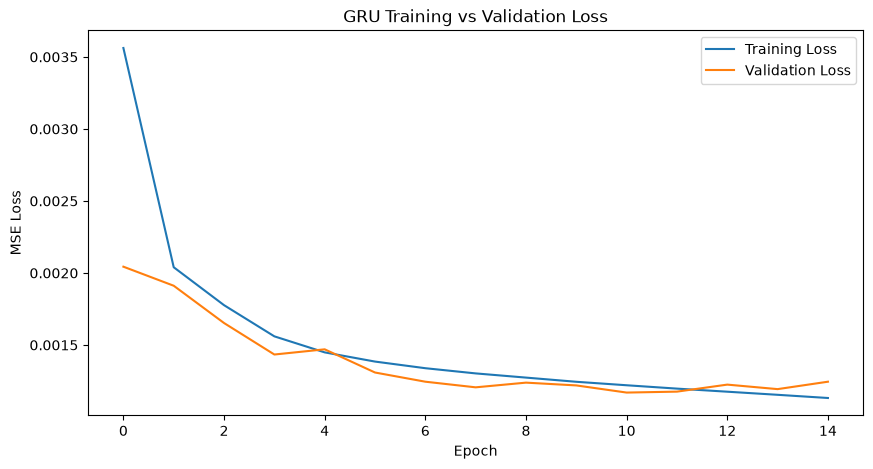

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_features.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_features.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "GRU Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.show()

In [34]:
#Build GRU + Dropout
from tensorflow.keras.layers import Dropout
def build_gru_dropout():

    model = Sequential([
        GRU(
            64,
            input_shape=(168, 9)
        ),

        Dropout(0.2),

        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [35]:
gru_dropout = build_gru_dropout()

history_dropout = gru_dropout.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 234s 65ms/step - loss: 0.0051 - val_loss: 0.0020
Epoch 2/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 229s 64ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 3/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 232s 64ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 4/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 230s 64ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 5/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 231s 64ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 6/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 233s 65ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 7/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 230s 64ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 8/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 235s 65ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 9/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 231s 64ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 10/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 230s 64ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 11/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 233s 65ms/step - loss: 0.0016 - val_loss: 0.00

In [36]:
pred_dropout = gru_dropout.predict(
    X_test,
    verbose=0
)

pred_dropout = inverse_target(pred_dropout)

metrics = evaluate_forecast(
    actual_test,
    pred_dropout
)

dropout_result = {
    "Experiment": "GRU + Lag + Rolling + Dropout",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

dropout_result

{'Experiment': 'GRU + Lag + Rolling + Dropout',
 'MAE': 1364.9627793883506,
 'MSE': 3659960.3007556144,
 'RMSE': np.float64(1913.1022713790328),
 'MAPE': np.float64(4.344613251012498),
 'R2': 0.9130490579448114,
 'Bias': np.float64(222.82578125954507)}

In [37]:
results.append(dropout_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline GRU,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106
1,GRU + Lag + Rolling Features,1344.752508,3.577181e+06,1891.343700,4.282023,0.915016,218.576061
2,GRU + Lag + Rolling + Dropout,1364.962779,3.659960e+06,1913.102271,4.344613,0.913049,222.825781


In [38]:
#bATCH nORMALIZATION
from tensorflow.keras.layers import BatchNormalization
def build_gru_batchnorm():

    model = Sequential([
        GRU(
            64,
            input_shape=(168, 9)
        ),

        BatchNormalization(),

        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [39]:
gru_batchnorm = build_gru_batchnorm()

history_batchnorm = gru_batchnorm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 233s 64ms/step - loss: 0.0083 - val_loss: 0.0110
Epoch 2/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 228s 63ms/step - loss: 0.0032 - val_loss: 0.0138
Epoch 3/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 231s 64ms/step - loss: 0.0029 - val_loss: 0.0230
Epoch 4/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 233s 65ms/step - loss: 0.0027 - val_loss: 0.0234
Epoch 5/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 246s 68ms/step - loss: 0.0026 - val_loss: 0.0630
Epoch 6/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 234s 65ms/step - loss: 0.0024 - val_loss: 0.0227


In [40]:
pred_batchnorm = gru_batchnorm.predict(
    X_test,
    verbose=0
)

pred_batchnorm = inverse_target(pred_batchnorm)

metrics = evaluate_forecast(
    actual_test,
    pred_batchnorm
)

batchnorm_result = {
    "Experiment": "GRU + Lag + Rolling + BatchNorm",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

batchnorm_result

{'Experiment': 'GRU + Lag + Rolling + BatchNorm',
 'MAE': 4283.947496829238,
 'MSE': 28591542.387250345,
 'RMSE': np.float64(5347.105982421738),
 'MAPE': np.float64(14.103206912486746),
 'R2': 0.3207408438640671,
 'Bias': np.float64(-295.4816516939211)}

In [41]:
results.append(batchnorm_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline GRU,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106
1,GRU + Lag + Rolling Features,1344.752508,3.577181e+06,1891.343700,4.282023,0.915016,218.576061
2,GRU + Lag + Rolling + Dropout,1364.962779,3.659960e+06,1913.102271,4.344613,0.913049,222.825781
3,GRU + Lag + Rolling + BatchNorm,4283.947497,2.859154e+07,5347.105982,14.103207,0.320741,-295.481652


In [42]:
#Build GRU with RMSprop
def build_gru_rmsprop():

    model = Sequential([
        GRU(
            64,
            input_shape=(168, 9)
        ),
        BatchNormalization(),
        Dense(24)
    ])

    model.compile(
        optimizer=RMSprop(learning_rate=0.001),
        loss="mse"
    )

    return model

In [43]:
gru_rmsprop = build_gru_rmsprop()

history_rmsprop = gru_rmsprop.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 228s 63ms/step - loss: 0.0086 - val_loss: 0.0085
Epoch 2/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 227s 63ms/step - loss: 0.0036 - val_loss: 0.0110
Epoch 3/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 232s 64ms/step - loss: 0.0031 - val_loss: 0.0044
Epoch 4/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 228s 63ms/step - loss: 0.0029 - val_loss: 0.0065
Epoch 5/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 229s 64ms/step - loss: 0.0028 - val_loss: 0.0046
Epoch 6/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 228s 63ms/step - loss: 0.0027 - val_loss: 0.0043
Epoch 7/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 227s 63ms/step - loss: 0.0027 - val_loss: 0.0049
Epoch 8/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 230s 64ms/step - loss: 0.0026 - val_loss: 0.0079
Epoch 9/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 228s 63ms/step - loss: 0.0026 - val_loss: 0.0064
Epoch 10/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 228s 63ms/step - loss: 0.0026 - val_loss: 0.0029
Epoch 11/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 231s 64ms/step - loss: 0.0025 - val_loss: 0.00

In [45]:
pred_rmsprop = gru_rmsprop.predict(
    X_test,
    verbose=0
)

pred_rmsprop = inverse_target(pred_rmsprop)

metrics = evaluate_forecast(
    actual_test,
    pred_rmsprop
)

rmsprop_result = {
    "Experiment": "GRU + Features + BatchNorm + RMSprop",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

rmsprop_result

{'Experiment': 'GRU + Features + BatchNorm + RMSprop',
 'MAE': 2040.9248260305742,
 'MSE': 7333190.476236105,
 'RMSE': np.float64(2707.9864246772186),
 'MAPE': np.float64(6.510526184012119),
 'R2': 0.8257828588885989,
 'Bias': np.float64(-657.7535873222886)}

In [46]:
results.append(rmsprop_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline GRU,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106
1,GRU + Lag + Rolling Features,1344.752508,3.577181e+06,1891.343700,4.282023,0.915016,218.576061
2,GRU + Lag + Rolling + Dropout,1364.962779,3.659960e+06,1913.102271,4.344613,0.913049,222.825781
3,GRU + Lag + Rolling + BatchNorm,4283.947497,2.859154e+07,5347.105982,14.103207,0.320741,-295.481652
4,GRU + Features + BatchNorm + RMSprop,2040.924826,7.333190e+06,2707.986425,6.510526,0.825783,-657.753587


In [47]:
#LEARING RATE 
from tensorflow.keras.callbacks import ReduceLROnPlateau
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [48]:
def build_gru_scheduler():

    model = Sequential([
        GRU(
            64,
            input_shape=(168, 9)
        ),
        BatchNormalization(),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [50]:
gru_scheduler = build_gru_scheduler()

history_scheduler = gru_scheduler.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=15,
    callbacks=[
        early_stopping,
        lr_scheduler
    ],
    verbose=1
)

Epoch 1/15
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 469s 61ms/step - loss: 0.0067 - val_loss: 0.0906 - learning_rate: 0.0010
Epoch 2/15
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 430s 56ms/step - loss: 0.0034 - val_loss: 0.0833 - learning_rate: 0.0010
Epoch 3/15
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 429s 56ms/step - loss: 0.0032 - val_loss: 0.0672 - learning_rate: 0.0010
Epoch 4/15
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 449s 59ms/step - loss: 0.0031 - val_loss: 0.0629 - learning_rate: 0.0010
Epoch 5/15
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 432s 56ms/step - loss: 0.0030 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 6/15
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 434s 57ms/step - loss: 0.0028 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 7/15
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 439s 57ms/step - loss: 0.0028 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 8/15
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 440s 57ms/step - loss: 0.0027 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 9/15
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 442s 57ms/step - loss: 0.0027 - val_lo

In [51]:
pred_scheduler = gru_scheduler.predict(
    X_test,
    verbose=0
)

pred_scheduler = inverse_target(pred_scheduler)

metrics = evaluate_forecast(
    actual_test,
    pred_scheduler
)

scheduler_result = {
    "Experiment": "GRU + Features + BatchNorm + LR Scheduler",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

scheduler_result

{'Experiment': 'GRU + Features + BatchNorm + LR Scheduler',
 'MAE': 1692.209191593019,
 'MSE': 5052011.387352468,
 'RMSE': np.float64(2247.6679886834863),
 'MAPE': np.float64(5.549312052691114),
 'R2': 0.879977619070582,
 'Bias': np.float64(941.8144087347746)}

In [52]:
results.append(scheduler_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline GRU,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106
1,GRU + Lag + Rolling Features,1344.752508,3.577181e+06,1891.343700,4.282023,0.915016,218.576061
2,GRU + Lag + Rolling + Dropout,1364.962779,3.659960e+06,1913.102271,4.344613,0.913049,222.825781
3,GRU + Lag + Rolling + BatchNorm,4283.947497,2.859154e+07,5347.105982,14.103207,0.320741,-295.481652
4,GRU + Features + BatchNorm + RMSprop,2040.924826,7.333190e+06,2707.986425,6.510526,0.825783,-657.753587
5,GRU + Features + BatchNorm + LR Scheduler,1692.209192,5.052011e+06,2247.667989,5.549312,0.879978,941.814409


In [53]:
#batch size tune
def build_gru_batchsize():

    model = Sequential([
        GRU(64, input_shape=(168, 9)),
        BatchNormalization(),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [55]:
batch_sizes = [16, 64]

batch_results = []

for batch_size in batch_sizes:

    print(f"\nBatch Size: {batch_size}")

    model = build_gru_batchsize()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=batch_size,
        callbacks=[
            early_stopping,
            lr_scheduler
        ],
        verbose=1
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    pred = inverse_target(pred)

    metrics = evaluate_forecast(
        actual_test,
        pred
    )

    batch_results.append({
        "Batch Size": batch_size,
        "MAE": metrics[0],
        "MSE": metrics[1],
        "RMSE": metrics[2],
        "MAPE": metrics[3],
        "R2": metrics[4],
        "Bias": metrics[5]
    })


Batch Size: 16
Epoch 1/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 417s 58ms/step - loss: 0.0071 - val_loss: 0.0550 - learning_rate: 0.0010
Epoch 2/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 411s 57ms/step - loss: 0.0033 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 3/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 416s 58ms/step - loss: 0.0031 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 4/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 413s 57ms/step - loss: 0.0030 - val_loss: 0.0274 - learning_rate: 0.0010
Epoch 5/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 412s 57ms/step - loss: 0.0028 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 6/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 416s 58ms/step - loss: 0.0027 - val_loss: 0.0490 - learning_rate: 0.0010
Epoch 7/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 413s 57ms/step - loss: 0.0026 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 8/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 412s 57ms/step - loss: 0.0026 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 9/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 416s 58ms/step - loss:

In [56]:
batch_df = pd.DataFrame(batch_results)

batch_df

,Batch Size,MAE,MSE,RMSE,MAPE,R2,Bias
0,16,2780.481958,1.305329e+07,3612.934198,9.224502,0.689888,1262.098328
1,64,2893.749202,1.281856e+07,3580.302135,9.508573,0.695465,-277.001614


In [57]:
best_batch = batch_df.loc[
    batch_df["RMSE"].idxmin()
]

best_batch

Batch Size    6.400000e+01
MAE           2.893749e+03
MSE           1.281856e+07
RMSE          3.580302e+03
MAPE          9.508573e+00
R2            6.954650e-01
Bias         -2.770016e+02
Name: 1, dtype: float64

In [58]:
best_batch_size = int(
    best_batch["Batch Size"]
)

print("Best Batch Size:", best_batch_size)

Best Batch Size: 64


In [67]:
best_batch = batch_df.loc[
    batch_df["RMSE"].idxmin()
]

best_batch_size = int(results.append(batch_results[1])

improvement_df = pd.DataFrame(results)

improvement_df
    best_batch["Batch Size"]
)

best_batch_result = {
    "Experiment": f"Best Batch Size ({best_batch_size})",
    "MAE": best_batch["MAE"],
    "MSE": best_batch["MSE"],
    "RMSE": best_batch["RMSE"],
    "MAPE": best_batch["MAPE"],
    "R2": best_batch["R2"],
    "Bias": best_batch["Bias"]
}

results.append(best_batch_result)

improvement_df = pd.DataFrame(results)

improvement_df

ValueError: dictionary update sequence element #0 has length 7; 2 is required

In [68]:
for i, item in enumerate(results):
    print(i, type(item), item)

0 <class 'dict'> {'Experiment': 'Phase 5 Baseline GRU', 'MAE': 1364.036036, 'MSE': 3715291, 'RMSE': 1927.508982, 'MAPE': 4.343224, 'R2': 0.911742, 'Bias': 331.006106}
1 <class 'dict'> {'Experiment': 'GRU + Lag + Rolling Features', 'MAE': 1344.7525077838422, 'MSE': 3577180.991042391, 'RMSE': np.float64(1891.3436998711766), 'MAPE': np.float64(4.282023275302831), 'R2': 0.9150156746211608, 'Bias': np.float64(218.57606111279702)}
2 <class 'dict'> {'Experiment': 'GRU + Lag + Rolling + Dropout', 'MAE': 1364.9627793883506, 'MSE': 3659960.3007556144, 'RMSE': np.float64(1913.1022713790328), 'MAPE': np.float64(4.344613251012498), 'R2': 0.9130490579448114, 'Bias': np.float64(222.82578125954507)}
3 <class 'dict'> {'Experiment': 'GRU + Lag + Rolling + BatchNorm', 'MAE': 4283.947496829238, 'MSE': 28591542.387250345, 'RMSE': np.float64(5347.105982421738), 'MAPE': np.float64(14.103206912486746), 'R2': 0.3207408438640671, 'Bias': np.float64(-295.4816516939211)}
4 <class 'dict'> {'Experiment': 'GRU + Fea

In [83]:
results

[{'Experiment': 'Phase 5 Baseline GRU',
  'MAE': 1364.036036,
  'MSE': 3715291,
  'RMSE': 1927.508982,
  'MAPE': 4.343224,
  'R2': 0.911742,
  'Bias': 331.006106},
 {'Experiment': 'GRU + Lag + Rolling Features',
  'MAE': 1344.7525077838422,
  'MSE': 3577180.991042391,
  'RMSE': np.float64(1891.3436998711766),
  'MAPE': np.float64(4.282023275302831),
  'R2': 0.9150156746211608,
  'Bias': np.float64(218.57606111279702)},
 {'Experiment': 'GRU + Lag + Rolling + Dropout',
  'MAE': 1364.9627793883506,
  'MSE': 3659960.3007556144,
  'RMSE': np.float64(1913.1022713790328),
  'MAPE': np.float64(4.344613251012498),
  'R2': 0.9130490579448114,
  'Bias': np.float64(222.82578125954507)},
 {'Experiment': 'GRU + Lag + Rolling + BatchNorm',
  'MAE': 4283.947496829238,
  'MSE': 28591542.387250345,
  'RMSE': np.float64(5347.105982421738),
  'MAPE': np.float64(14.103206912486746),
  'R2': 0.3207408438640671,
  'Bias': np.float64(-295.4816516939211)},
 {'Experiment': 'GRU + Features + BatchNorm + RMSprop'

In [73]:
#number of layers
architectures = {
    "GRU_32": [32],

    "GRU_128": [128]
}

In [74]:
architecture_results = []

for name, units in architectures.items():

    print(f"\nTraining: {name}")

    model = Sequential()

    for i, unit in enumerate(units):

        model.add(
            GRU(
                unit,
                return_sequences=(i < len(units) - 1),
                input_shape=(168, 9) if i == 0 else None
            )
        )

    model.add(BatchNormalization())
    model.add(Dense(24))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=best_batch_size,
        callbacks=[
            early_stopping,
            lr_scheduler
        ],
        verbose=1
    )

    print(f"Predicting: {name}")

    pred = model.predict(
        X_test,
        verbose=0
    )

    pred = inverse_target(pred)

    metrics = evaluate_forecast(
        actual_test,
        pred
    )

    architecture_results.append({
        "Architecture": name,
        "MAE": metrics[0],
        "MSE": metrics[1],
        "RMSE": metrics[2],
        "MAPE": metrics[3],
        "R2": metrics[4],
        "Bias": metrics[5]
    })

    print(f"Finished: {name}")


Training: GRU_32
Epoch 1/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 107s 59ms/step - loss: 0.0170 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 2/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 108s 60ms/step - loss: 0.0035 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 3/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 106s 59ms/step - loss: 0.0030 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 4/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 108s 60ms/step - loss: 0.0028 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 5/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0027
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 108s 60ms/step - loss: 0.0027 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 6/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 108s 60ms/step - loss: 0.0025 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 7/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 107s 60ms/step - loss: 0.0025 - val_loss: 0.0026 - learning_rate: 5.0000e-04
Epoch 8/15
1799/1799 ━━━━━━━━━━━━━

In [75]:
architecture_df = pd.DataFrame(
    architecture_results
)

architecture_df

,Architecture,MAE,MSE,RMSE,MAPE,R2,Bias
0,GRU_32,1702.463859,5.311741e+06,2304.721406,5.41203,0.873807,-324.145923
1,GRU_128,1569.701450,4.482433e+06,2117.175813,5.00225,0.893509,-147.454441


In [76]:
best_architecture = architecture_df.loc[
    architecture_df["RMSE"].idxmin()
]

best_architecture

Architecture           GRU_128
MAE                 1569.70145
MSE             4482433.425007
RMSE               2117.175813
MAPE                   5.00225
R2                    0.893509
Bias               -147.454441
Name: 1, dtype: object

In [77]:
results.append(scheduler_result)

improvement_df = pd.DataFrame(architecture_results)

improvement_df

,Architecture,MAE,MSE,RMSE,MAPE,R2,Bias
0,GRU_32,1702.463859,5.311741e+06,2304.721406,5.41203,0.873807,-324.145923
1,GRU_128,1569.701450,4.482433e+06,2117.175813,5.00225,0.893509,-147.454441


In [85]:
best_arch = architecture_df.loc[
    architecture_df["RMSE"].idxmin()
]

architecture_result = {
    "Experiment": f"Architecture ({best_arch['Architecture']})",
    "MAE": best_arch["MAE"],
    "MSE": best_arch["MSE"],
    "RMSE": best_arch["RMSE"],
    "MAPE": best_arch["MAPE"],
    "R2": best_arch["R2"],
    "Bias": best_arch["Bias"]
}

results.append(architecture_result)

In [86]:

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias,Batch Size
0,Phase 5 Baseline GRU,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106,NaN
1,GRU + Lag + Rolling Features,1344.752508,3.577181e+06,1891.343700,4.282023,0.915016,218.576061,NaN
2,GRU + Lag + Rolling + Dropout,1364.962779,3.659960e+06,1913.102271,4.344613,0.913049,222.825781,NaN
3,GRU + Lag + Rolling + BatchNorm,4283.947497,2.859154e+07,5347.105982,14.103207,0.320741,-295.481652,NaN
4,GRU + Features + BatchNorm + RMSprop,2040.924826,7.333190e+06,2707.986425,6.510526,0.825783,-657.753587,NaN
5,GRU + Features + BatchNorm + LR Scheduler,1692.209192,5.052011e+06,2247.667989,5.549312,0.879978,941.814409,NaN
6,NaN,2893.749202,1.281856e+07,3580.302135,9.508573,0.695465,-277.001614,64.0
7,Best Batch Size (64),2893.749202,1.281856e+07,3580.302135,9.508573,0.695465,-277.001614,NaN
8,GRU + Features + BatchNorm + LR Scheduler,1692.209192,5.052011e+06,2247.667989,5.549312,0.879978,941.814409,NaN
9,Architecture (GRU_128),1569.701450,4.482433e+06,2117.175813,5.002250,0.893509,-147.454441,NaN


In [88]:
import keras_tuner as kt

In [89]:
def build_tuned_gru(hp):

    model = Sequential()

    model.add(
        GRU(
            units=hp.Choice(
                "gru_units",
                [32, 64, 128]
            ),
            input_shape=(168, 9)
        )
    )

    model.add(
        Dropout(
            hp.Float(
                "dropout",
                0.1,
                0.4,
                step=0.1
            )
        )
    )

    model.add(Dense(24))

    optimizer_name = hp.Choice(
        "optimizer",
        ["adam", "rmsprop"]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        [0.001, 0.0005, 0.0001]
    )

    if optimizer_name == "adam":
        optimizer = Adam(
            learning_rate=learning_rate
        )
    else:
        optimizer = RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    return model

In [90]:
tuner = kt.RandomSearch(
    build_tuned_gru,

    objective="val_loss",

    max_trials=3,

    directory="phase6_tuning",

    project_name="gru_forecasting",

    overwrite=True
)

In [91]:
tuner.search(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=15,

    batch_size=best_batch_size,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Trial 3 Complete [00h 27m 27s]
val_loss: 0.0018065818585455418

Best val_loss So Far: 0.0018065818585455418
Total elapsed time: 01h 33m 35s


In [92]:
best_hp = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print(
    "GRU Units:",
    best_hp.get("gru_units")
)

print(
    "Dropout:",
    best_hp.get("dropout")
)

print(
    "Optimizer:",
    best_hp.get("optimizer")
)

print(
    "Learning Rate:",
    best_hp.get("learning_rate")
)

GRU Units: 32
Dropout: 0.30000000000000004
Optimizer: adam
Learning Rate: 0.0005


In [93]:
best_model = tuner.get_best_models(
    num_models=1
)[0]

In [94]:
pred_tuned = best_model.predict(
    X_test,
    verbose=0
)

pred_tuned = inverse_target(
    pred_tuned
)

metrics = evaluate_forecast(
    actual_test,
    pred_tuned
)

tuned_result = {
    "Experiment": "GRU Hyperparameter Tuning",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

tuned_result

{'Experiment': 'GRU Hyperparameter Tuning',
 'MAE': 1592.599502632959,
 'MSE': 4657884.031679117,
 'RMSE': np.float64(2158.2131571462346),
 'MAPE': np.float64(5.205846076447189),
 'R2': 0.88934103890288,
 'Bias': np.float64(513.7109967243989)}

In [95]:
results.append(tuned_result)

final_results = pd.DataFrame(results)

final_results

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias,Batch Size
0,Phase 5 Baseline GRU,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106,NaN
1,GRU + Lag + Rolling Features,1344.752508,3.577181e+06,1891.343700,4.282023,0.915016,218.576061,NaN
2,GRU + Lag + Rolling + Dropout,1364.962779,3.659960e+06,1913.102271,4.344613,0.913049,222.825781,NaN
3,GRU + Lag + Rolling + BatchNorm,4283.947497,2.859154e+07,5347.105982,14.103207,0.320741,-295.481652,NaN
4,GRU + Features + BatchNorm + RMSprop,2040.924826,7.333190e+06,2707.986425,6.510526,0.825783,-657.753587,NaN
5,GRU + Features + BatchNorm + LR Scheduler,1692.209192,5.052011e+06,2247.667989,5.549312,0.879978,941.814409,NaN
6,NaN,2893.749202,1.281856e+07,3580.302135,9.508573,0.695465,-277.001614,64.0
7,Best Batch Size (64),2893.749202,1.281856e+07,3580.302135,9.508573,0.695465,-277.001614,NaN
8,GRU + Features + BatchNorm + LR Scheduler,1692.209192,5.052011e+06,2247.667989,5.549312,0.879978,941.814409,NaN
9,Architecture (GRU_128),1569.701450,4.482433e+06,2117.175813,5.002250,0.893509,-147.454441,NaN


In [96]:
final_results = pd.DataFrame(results)

final_results.sort_values(
    "RMSE"
)

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias,Batch Size
1,GRU + Lag + Rolling Features,1344.752508,3.577181e+06,1891.343700,4.282023,0.915016,218.576061,NaN
2,GRU + Lag + Rolling + Dropout,1364.962779,3.659960e+06,1913.102271,4.344613,0.913049,222.825781,NaN
0,Phase 5 Baseline GRU,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106,NaN
9,Architecture (GRU_128),1569.701450,4.482433e+06,2117.175813,5.002250,0.893509,-147.454441,NaN
10,GRU Hyperparameter Tuning,1592.599503,4.657884e+06,2158.213157,5.205846,0.889341,513.710997,NaN
8,GRU + Features + BatchNorm + LR Scheduler,1692.209192,5.052011e+06,2247.667989,5.549312,0.879978,941.814409,NaN
5,GRU + Features + BatchNorm + LR Scheduler,1692.209192,5.052011e+06,2247.667989,5.549312,0.879978,941.814409,NaN
4,GRU + Features + BatchNorm + RMSprop,2040.924826,7.333190e+06,2707.986425,6.510526,0.825783,-657.753587,NaN
6,NaN,2893.749202,1.281856e+07,3580.302135,9.508573,0.695465,-277.001614,64.0
7,Best Batch Size (64),2893.749202,1.281856e+07,3580.302135,9.508573,0.695465,-277.001614,NaN


In [97]:
best_result = final_results.loc[
    final_results["RMSE"].idxmin()
]

best_result

Experiment    GRU + Lag + Rolling Features
MAE                            1344.752508
MSE                         3577180.991042
RMSE                             1891.3437
MAPE                              4.282023
R2                                0.915016
Bias                            218.576061
Batch Size                             NaN
Name: 1, dtype: object

In [98]:
best_rmse = best_result["RMSE"]
best_mae = best_result["MAE"]
best_mape = best_result["MAPE"]
best_r2 = best_result["R2"]

In [99]:
baseline_rmse = 1927.508982
baseline_mae = 1364.036036
baseline_mape = 4.343224
baseline_r2 = 0.911742

In [100]:
rmse_improvement = (
    (baseline_rmse - best_rmse)
    / baseline_rmse
) * 100

print(f"RMSE Improvement: {rmse_improvement:.2f}%")

RMSE Improvement: 1.88%


In [101]:
comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ],

    "Phase 5 Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_mape,
        baseline_r2
    ],

    "Phase 6 Final": [
        best_mae,
        best_rmse,
        best_mape,
        best_r2
    ]
})

comparison

,Metric,Phase 5 Baseline,Phase 6 Final
0,MAE,1364.036036,1344.752508
1,RMSE,1927.508982,1891.343700
2,MAPE,4.343224,4.282023
3,R2,0.911742,0.915016


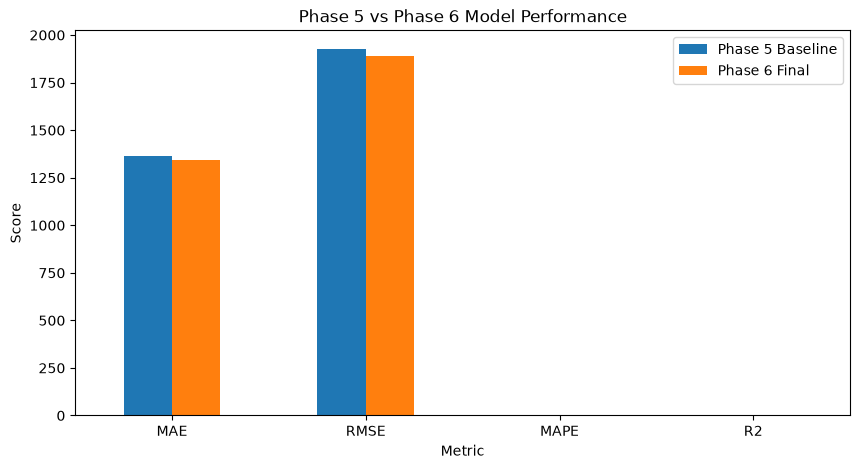

In [102]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Phase 5 vs Phase 6 Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [104]:
best_model.save(
    "final_gru_forecasting_model.keras"
)

In [105]:
final_results.to_csv(
    "phase6_model_improvement_results.csv",
    index=False
)

In [107]:
comparison.to_csv(
    "phase5_vs_phase6_comparison.csv",
    index=False
)